# Program 3 - CNN Architecture — MNIST Digit Classification

A clean, modular Convolutional Neural Network built with **PyTorch** to classify handwritten digits from the MNIST dataset.

**Architecture overview**
```
Input (1×28×28)
  → [Conv2d(1→32) + BN + ReLU + MaxPool]   →  (32×14×14)
  → [Conv2d(32→64) + BN + ReLU + MaxPool]  →  (64×7×7)
  → Flatten → Linear(3136→128) + ReLU + Dropout(0.5)
  → Linear(128→10)   ← logits
```


## 1 · Install Dependencies

In [6]:
!pip install torch torchvision

   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/123.0 MB 2.5 MB/s eta 0:00:50
   ---------------------------------------- 1.0/123.0 MB 2.1 MB/s eta 0:00:58
   ---------------------------------------- 1.3/123.0 MB 2.3 MB/s eta 0:00:54
    --------------------------------------- 2.1/123.0 MB 2.4 MB/s eta 0:00:50
   - -------------------------------------- 3.1/123.0 MB 2.9 MB/s eta 0:00:42
   - -------------------------------------- 3.9/123.0 MB 3.1 MB/s eta 0:00:39
   - -------------------------------------- 5.0/123.0 MB 3.5 MB/s eta 0:00:34
   - -------------------------------------- 6.0/123.0 MB 3.6 MB/s eta 0:00:33
   -- ------------------------------------- 6.8/123.0 MB 3.6 MB/s eta 0:00:33
   --- ------------------------------------ 9.4/123.0 MB 4.6 MB/s eta 0:00:25
   --- ------------------------------------ 11.5/123.0 MB 5.0 MB/s eta 0:00:23

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, which is not installed.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.4.6 which is incompatible.
streamlit 1.45.1 requires packaging<25,>=20, but you have packaging 25.0 which is incompatible.


   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 [torch]
   ------------- -------------------------- 1/3 

## 2 · Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")


PyTorch version : 2.12.0+cpu
CUDA available  : False


## 3 · Hyperparameters

In [9]:
EPOCHS     = 5
BATCH_SIZE = 64
LR         = 1e-3
SAVE_PATH  = "cnn_mnist.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 4 · Dataset & DataLoaders

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))   # MNIST mean & std
])

train_set = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_set  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples : {len(train_set):,}")
print(f"Test  samples : {len(test_set):,}")


Train samples : 60,000
Test  samples : 10,000


### 4.1 · Visualise Sample Images

F:\PROGRAMMING LANGUAGES\Anaconda\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


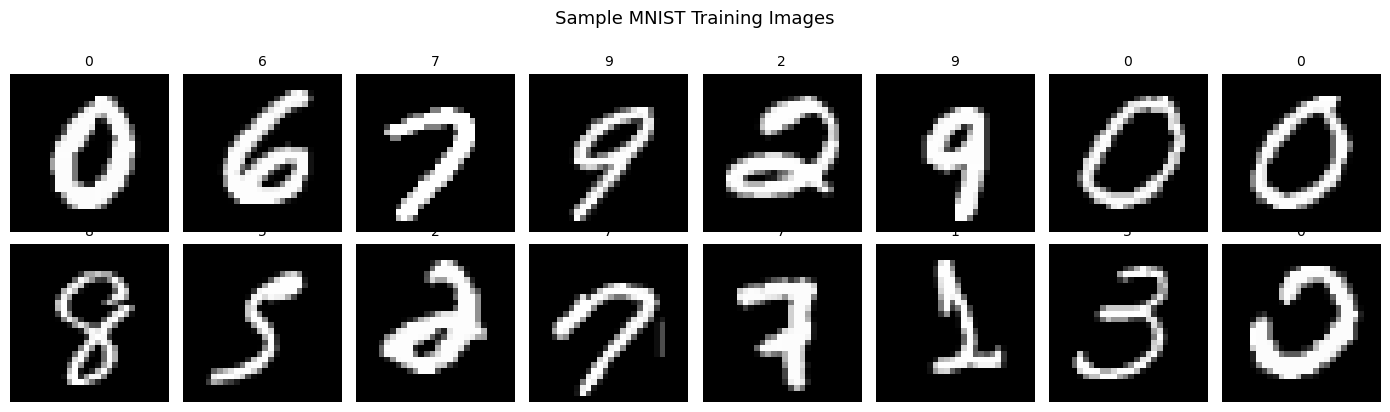

In [4]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(str(labels[i].item()), fontsize=10)
    ax.axis("off")
plt.suptitle("Sample MNIST Training Images", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 5 · CNN Model Definition

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Block 1: 1 → 32 feature maps  (28×28 → 14×14)
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 2: 32 → 64 feature maps  (14×14 → 7×7)
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Fully-connected head
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 10)          # 10 digit classes — raw logits
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.fc(x)
        return x


model = CNN().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total parameters: 421,834


## 6 · Loss Function & Optimiser

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print("Loss      :", criterion)
print("Optimizer :", optimizer.__class__.__name__)
print("Scheduler :", scheduler.__class__.__name__)


Loss      : CrossEntropyLoss()
Optimizer : Adam
Scheduler : StepLR


## 7 · Training & Evaluation Helpers

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


## 8 · Training Loop

In [10]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

header = f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Test Loss':>9}  {'Test Acc':>8}"
print(header)
print("─" * len(header))

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    te_loss, te_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2%}  {te_loss:>9.4f}  {te_acc:>7.2%}")

torch.save(model.state_dict(), SAVE_PATH)
print(f"\nWeights saved → {SAVE_PATH}")


Epoch  Train Loss  Train Acc  Test Loss  Test Acc
─────────────────────────────────────────────────
    1      0.1412    95.83%     0.0412   98.70%
    2      0.1003    96.99%     0.0374   98.83%
    3      0.0825    97.56%     0.0287   99.11%
    4      0.0672    98.00%     0.0253   99.17%
    5      0.0591    98.24%     0.0262   99.16%

Weights saved → cnn_mnist.pth


## 9 · Training Curves

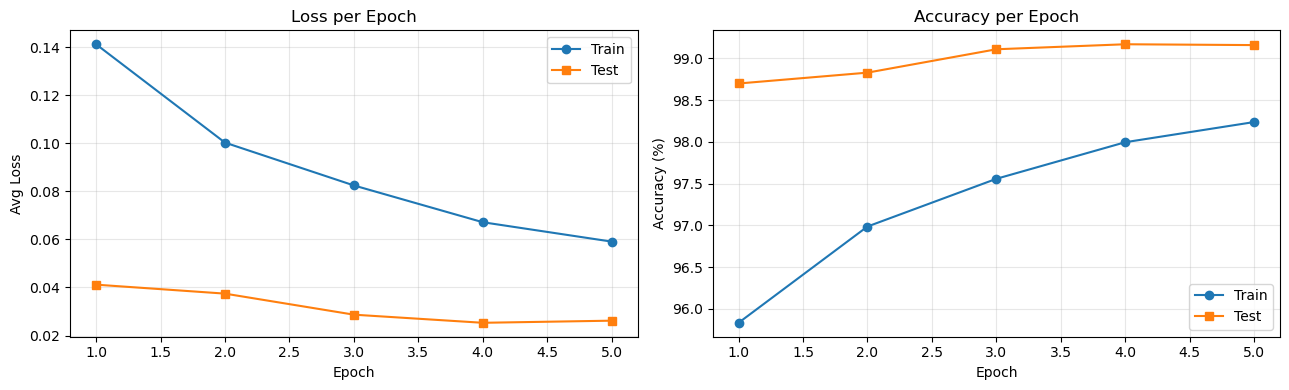

Final test accuracy: 99.16%


In [11]:
epochs = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Loss
ax1.plot(epochs, history["train_loss"], label="Train", marker="o")
ax1.plot(epochs, history["test_loss"],  label="Test",  marker="s")
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Avg Loss")
ax1.legend(); ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(epochs, [a*100 for a in history["train_acc"]], label="Train", marker="o")
ax2.plot(epochs, [a*100 for a in history["test_acc"]],  label="Test",  marker="s")
ax2.set_title("Accuracy per Epoch")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Final test accuracy: {history['test_acc'][-1]:.2%}")


## 10 · Inference on Test Samples

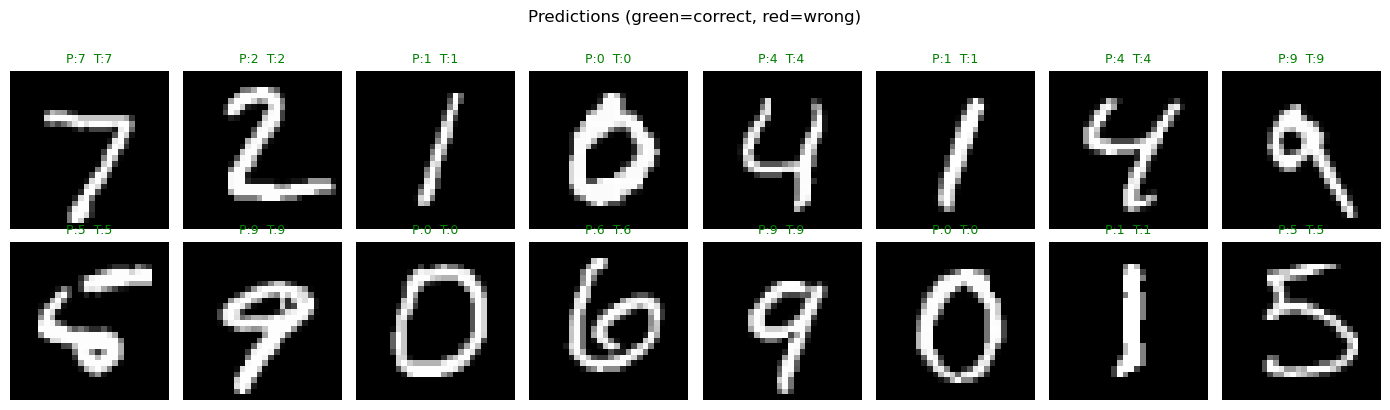

In [12]:
model.eval()
sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:16]
sample_labels = sample_labels[:16]

with torch.no_grad():
    preds = model(sample_images.to(device)).argmax(1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].squeeze(), cmap="gray")
    color = "green" if preds[i] == sample_labels[i] else "red"
    ax.set_title(f"P:{preds[i]}  T:{sample_labels[i]}", fontsize=9, color=color)
    ax.axis("off")
plt.suptitle("Predictions (green=correct, red=wrong)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
